In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


- V1: yindex范围 [0, 270], 共 271 个神经元
- V4: yindex范围 [271, 395], 共 125 个神经元
- IT: yindex范围 [396, 502], 共 107 个神经元

In [4]:
monkeyF_feature = pd.read_csv("/media/ubuntu/sda/Monkey/image_feature/neuron_preferred_axes_results.csv")

In [8]:
monkeyF_feature['region'] = 'V1'
monkeyF_feature.loc[271:395, 'region'] = "IT"
monkeyF_feature.loc[396:, 'region'] = 'V4'

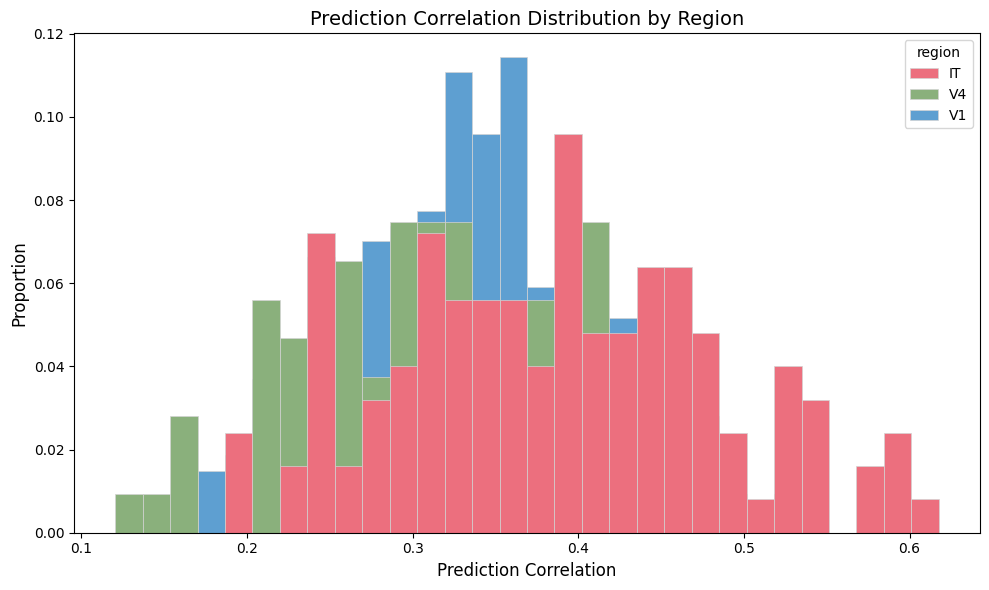

In [18]:
from matplotlib.backends.backend_pdf import PdfPages


color_palette = {'V4': '#8AB07C', 'V1': '#5E9FD1', 'IT': '#EC6F7E'}  # 绿色、蓝色、红色
hue_order = ['IT', 'V4', 'V1']  # 控制图例顺序：绿色、蓝色、红色

with PdfPages("/media/ubuntu/sda/Monkey/image_feature/prediction_correlation_by_region.pdf") as pdf:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=monkeyF_feature, x='prediction_correlation', hue='region', 
                bins=30, alpha=1, common_norm=False, stat='probability',
                palette=color_palette, hue_order=hue_order, edgecolor='lightgray', linewidth=0.5)
    plt.xlabel('Prediction Correlation', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.title('Prediction Correlation Distribution by Region', fontsize=14)
    plt.tight_layout()
    pdf.savefig()
    plt.show()


In [11]:
from scipy.stats import ttest_ind

# 提取三个region的prediction_correlation数据
v1_data = monkeyF_feature[monkeyF_feature['region'] == 'V1']['prediction_correlation']
v4_data = monkeyF_feature[monkeyF_feature['region'] == 'V4']['prediction_correlation']
it_data = monkeyF_feature[monkeyF_feature['region'] == 'IT']['prediction_correlation']

# 进行两两t-test比较
print("=" * 60)
print("T-test 结果 (prediction_correlation)")
print("=" * 60)

# V1 vs V4
stat_v1_v4, pval_v1_v4 = ttest_ind(v1_data, v4_data)
print(f"\nV1 vs V4:")
print(f"  统计量 (t-statistic): {stat_v1_v4:.4f}")
print(f"  p值: {pval_v1_v4:.6f}")
print(f"  显著性: {'***' if pval_v1_v4 < 0.001 else '**' if pval_v1_v4 < 0.01 else '*' if pval_v1_v4 < 0.05 else 'ns'}")
print(f"  V1均值: {v1_data.mean():.4f}, V4均值: {v4_data.mean():.4f}")

# V1 vs IT
stat_v1_it, pval_v1_it = ttest_ind(v1_data, it_data)
print(f"\nV1 vs IT:")
print(f"  统计量 (t-statistic): {stat_v1_it:.4f}")
print(f"  p值: {pval_v1_it:.6f}")
print(f"  显著性: {'***' if pval_v1_it < 0.001 else '**' if pval_v1_it < 0.01 else '*' if pval_v1_it < 0.05 else 'ns'}")
print(f"  V1均值: {v1_data.mean():.4f}, IT均值: {it_data.mean():.4f}")

# V4 vs IT
stat_v4_it, pval_v4_it = ttest_ind(v4_data, it_data)
print(f"\nV4 vs IT:")
print(f"  统计量 (t-statistic): {stat_v4_it:.4f}")
print(f"  p值: {pval_v4_it:.6f}")
print(f"  显著性: {'***' if pval_v4_it < 0.001 else '**' if pval_v4_it < 0.01 else '*' if pval_v4_it < 0.05 else 'ns'}")
print(f"  V4均值: {v4_data.mean():.4f}, IT均值: {it_data.mean():.4f}")

print("\n" + "=" * 60)
print("显著性水平: *** p<0.001, ** p<0.01, * p<0.05, ns: 不显著")
print("=" * 60)


T-test 结果 (prediction_correlation)

V1 vs V4:
  统计量 (t-statistic): -0.7129
  p值: 0.476350
  显著性: ns
  V1均值: 0.3202, V4均值: 0.3262

V1 vs IT:
  统计量 (t-statistic): -8.0713
  p值: 0.000000
  显著性: ***
  V1均值: 0.3202, IT均值: 0.3879

V4 vs IT:
  统计量 (t-statistic): -5.0290
  p值: 0.000001
  显著性: ***
  V4均值: 0.3262, IT均值: 0.3879

显著性水平: *** p<0.001, ** p<0.01, * p<0.05, ns: 不显著


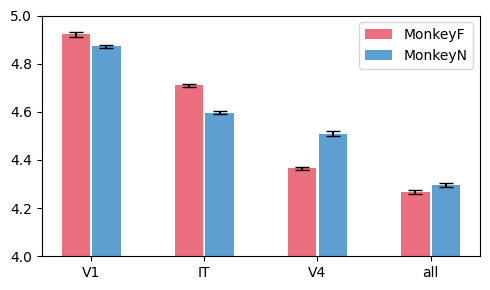

In [15]:
monkeyF_results = pd.read_csv("/media/ubuntu/sda/Monkey/image_feature/MonkeyF_results_matrix.csv", index_col=0)
monkeyN_results = pd.read_csv("/media/ubuntu/sda/Monkey/image_feature/MonkeyN_results_matrix.csv", index_col=0)

regions_order = ['V1', 'IT', 'V4', 'all']

monkeyF_means = []
monkeyF_stds = []
monkeyN_means = []
monkeyN_stds = []

for region in regions_order:
    monkeyF_means.append(monkeyF_results.loc[region].mean())
    monkeyF_stds.append(monkeyF_results.loc[region].std())
    monkeyN_means.append(monkeyN_results.loc[region].mean())
    monkeyN_stds.append(monkeyN_results.loc[region].std())

x = np.arange(len(regions_order))
width = 0.25

fig, ax = plt.subplots(figsize=(5, 3))

bars1 = ax.bar(x - width/2 - 0.01, monkeyF_means, width, yerr=monkeyF_stds, 
               label='MonkeyF', capsize=5, color='#EC6F7E')
bars2 = ax.bar(x + width/2 + 0.01, monkeyN_means, width, yerr=monkeyN_stds, 
               label='MonkeyN', capsize=5, color='#5E9FD1')
ax.set_xticks(x)
ax.set_xticklabels(regions_order)
ax.set_ylim(4, 5)
ax.legend()

plt.tight_layout()
plt.savefig("/media/ubuntu/sda/Monkey/image_feature/loss_by_region_errorbar.pdf")
plt.show()
